# Ball Balance — Training
PPO via rsl-rl-lib >= 5. Unitree G1 fixed-base humanoid.  
Runs on Kaggle GPU or locally for testing.

In [1]:
# ── 1. Per-run config ─────────────────────────────────────────────────────
import os

ON_KAGGLE = os.path.exists('/kaggle')

BRANCH         = 'dev'
TASK           = 'BallBalance-DualArm-Attention-v0'   # any registered gym env ID
EXP_NAME       = 'BallBalance-DualArm-Attention-v0'
N_ENVS         = 1024 if ON_KAGGLE else 4
MAX_ITERATIONS = 500 if ON_KAGGLE else 5
ACTION_DELTA   = 0.3

REPO_DIR = '/kaggle/working/bimanual-project' if ON_KAGGLE else os.path.abspath('.')
# LOG_DIR is set after training since the timestamp is generated by train.py

print(f'ON_KAGGLE: {ON_KAGGLE}')
print(f'TASK:      {TASK}')
print(f'REPO_DIR:  {REPO_DIR}')


ON_KAGGLE: True
TASK:      BallBalance-DualArm-Attention-v0
REPO_DIR:  /kaggle/working/bimanual-project


In [2]:
# ── 2. Clone / pull repo  (Kaggle only) ───────────────────────────────────
if ON_KAGGLE:
    from kaggle_secrets import UserSecretsClient
    import subprocess

    token = UserSecretsClient().get_secret('GITHUB_TOKEN')

    if not os.path.exists(REPO_DIR):
        result = subprocess.run([
            'git', 'clone', '--branch', BRANCH,
            f'https://{token}@github.com/sharana-sabesan09/bimanual-project.git',
            REPO_DIR,
        ], capture_output=True, text=True)
        print(result.stdout or result.stderr)
    else:
        result = subprocess.run(
            ['git', '-C', REPO_DIR, 'pull'],
            capture_output=True, text=True
        )
        print(result.stdout)

    commit = subprocess.run(
        ['git', '-C', REPO_DIR, 'log', '-1', '--pretty=%h %s'],
        capture_output=True, text=True
    )
    print('Commit:', commit.stdout.strip())
else:
    import subprocess
    commit = subprocess.run(
        ['git', 'log', '-1', '--pretty=%h %s'],
        capture_output=True, text=True
    )
    print('Local repo — commit:', commit.stdout.strip())

Cloning into '/kaggle/working/bimanual-project'...

Commit: cf50e96 Merge branch 'claude-goes-crazy-on-attention' into dev


In [3]:
!git pull

fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [4]:
# ── 3. Install dependencies  (Kaggle only) ────────────────────────────────
if ON_KAGGLE:
    import subprocess
    subprocess.run(['pip', 'install', '-r', f'{REPO_DIR}/requirements.txt', '-q'], check=True)
    print('Dependencies installed.')
else:
    print('Local — skipping installs.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.2/408.2 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.9/92.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.6/537.6 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/12

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65

Dependencies installed.


In [5]:
# ── 4. Setup paths ────────────────────────────────────────────────────────
import sys

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

print(f'Working dir: {os.getcwd()}')
# print(f'Log dir:     {LOG_DIR}')

Working dir: /kaggle/working/bimanual-project


In [6]:
# ── 5. Verify GPU ─────────────────────────────────────────────────────────
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU:  {props.name}')
    print(f'VRAM: {props.total_memory / 1e9:.1f} GB')
else:
    print('No GPU — training will use CPU (fine for local testing, slow for real runs)')

CUDA available: True
GPU:  Tesla T4
VRAM: 15.6 GB


In [7]:
# ── 7. Train ──────────────────────────────────────────────────────────────
cmd = (
    f"python scripts/rsl_rl/train.py"
    f" --task {TASK}"
    f" -e {EXP_NAME}"
    f" -n {N_ENVS}"
    f" --max_iterations {MAX_ITERATIONS}"
    f" --action_delta {ACTION_DELTA}"
    f" --headless"
)

print(f'Running: {cmd}')
!{cmd}

# pick up the timestamped run dir created by train.py
import glob
runs = sorted(glob.glob(os.path.join(REPO_DIR, "logs", EXP_NAME, "*")))
LOG_DIR = runs[-1]  # most recent
print(f'Log dir: {LOG_DIR}')


Running: python scripts/rsl_rl/train.py --task BallBalance-DualArm-Attention-v0 -e BallBalance-DualArm-Attention-v0 -n 1024 --max_iterations 500 --action_delta 0.3 --headless
/kaggle/working/bimanual-project/scripts/rsl_rl/train.py:5: SyntaxWarning: invalid escape sequence '\_'
  Available tasks (defined in source/tasks/*/\_\_init\_\_.py):
2026-06-01 07:42:47.228327: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780299767.593243     121 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780299767.713763     121 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780299768.680747     121 computation_placer.cc:177] computation placer already reg

2026-06-01 12:07:19.549990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780315639.577956      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780315639.587493      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780315639.612284      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780315639.612314      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780315639.612317      23 computation_placer.cc:177] computation placer alr

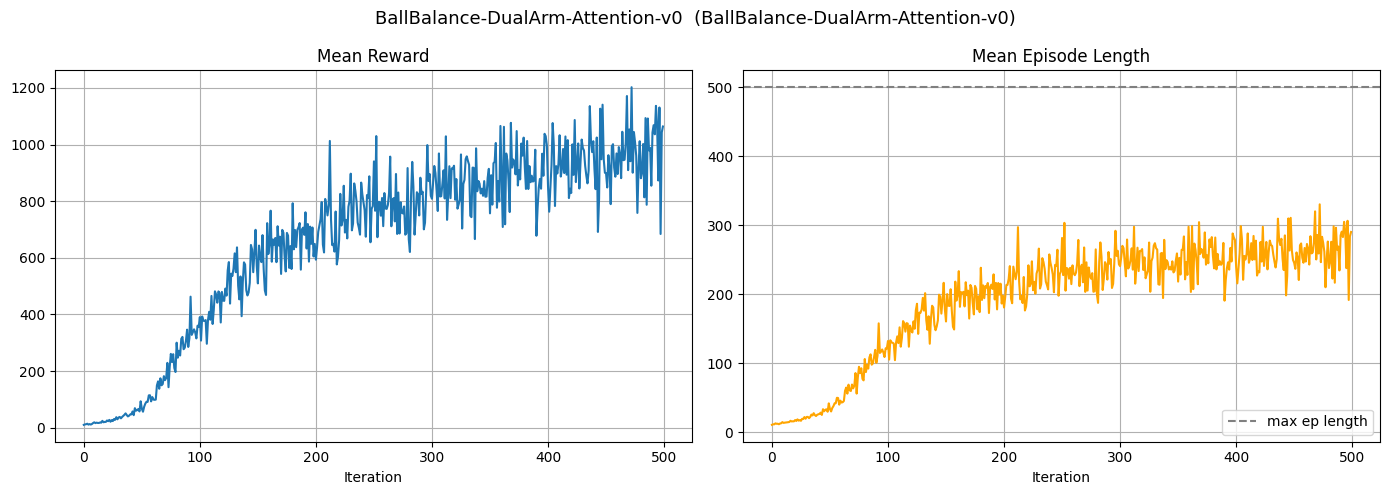

Final reward: 1063.64  (best 1202.43)
Final ep len: 290.2  (best 330.2 / 500)


In [8]:
# ── 8. Plot training curves ───────────────────────────────────────────────
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(LOG_DIR)
ea.Reload()

def extract(tag):
    events = ea.Scalars(tag)
    return [e.step for e in events], [e.value for e in events]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

steps, vals = extract('Train/mean_reward')
axes[0].plot(steps, vals)
axes[0].set_title('Mean Reward')
axes[0].set_xlabel('Iteration')
axes[0].grid(True)

steps, vals = extract('Train/mean_episode_length')
axes[1].plot(steps, vals, color='orange')
axes[1].axhline(500, color='gray', linestyle='--', label='max ep length')
axes[1].set_title('Mean Episode Length')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'{EXP_NAME}  ({TASK})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'training_curves.png'), dpi=150)
plt.show()

_, rewards = extract('Train/mean_reward')
_, ep_lens = extract('Train/mean_episode_length')
print(f'Final reward: {rewards[-1]:.2f}  (best {max(rewards):.2f})')
print(f'Final ep len: {ep_lens[-1]:.1f}  (best {max(ep_lens):.1f} / 500)')

In [9]:
# ── 9. Confirm outputs ────────────────────────────────────────────────────
print(f'Files in {LOG_DIR}:')
for f in sorted(os.listdir(LOG_DIR)):
    size = os.path.getsize(os.path.join(LOG_DIR, f)) / 1e6
    print(f'  {f}  ({size:.1f} MB)')

Files in /kaggle/working/bimanual-project/logs/BallBalance-DualArm-Attention-v0/2026-06-01_07-43-11-BallBalance-DualArm-Attention-v0:
  events.out.tfevents.1780299933.1d1b0ae8087a.121.0  (0.5 MB)
  git  (0.0 MB)
  model_0.pt  (9.0 MB)
  model_100.pt  (9.0 MB)
  model_200.pt  (9.0 MB)
  model_300.pt  (9.0 MB)
  model_400.pt  (9.0 MB)
  model_499.pt  (9.0 MB)
  train_cfg.pkl  (0.0 MB)
  training_curves.png  (0.2 MB)
